## **_Proyecto - Metodos Numericos_**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CONFIGURACIÓN DE ESTILO DE GRÁFICAS

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

**_1. DATOS EXPERIMENTALES_**

In [2]:
datos = {
    'tiempo': [0, 5, 10, 15, 20, 25],      # minutos
    'temperatura': [95, 82, 70, 60, 52, 46]  # grados Celsius
}

df = pd.DataFrame(datos)

print("1. DATOS EXPERIMENTALES")
print(df.to_string(index=False))

1. DATOS EXPERIMENTALES
 tiempo  temperatura
      0           95
      5           82
     10           70
     15           60
     20           52
     25           46


**_2. AJUSTE CUADRÁTICO POR MÍNIMOS CUADRADOS_**

In [3]:
def T_cuadratico(t, a, b, c):
    """
    Función cuadrática para modelar el enfriamiento.
    T(t) = a*t² + b*t + c
    
    Parámetros:
    - t: tiempo (minutos)
    - a, b, c: coeficientes del polinomio
    
    Retorna:
    - Temperatura en el tiempo t
    """
    return a * t**2 + b * t + c

# Extraer datos
t = df['tiempo'].values
T = df['temperatura'].values

# Ajuste por mínimos cuadrados
print("2. AJUSTE DE LA FUNCIÓN CUADRÁTICA")

parametros, covarianza = curve_fit(T_cuadratico, t, T)
a, b, c = parametros

# Calcular errores de los coeficientes
errores_coef = np.sqrt(np.diag(covarianza))

print(f"Coeficientes encontrados:")
print(f"  a = {a:.6f} ± {errores_coef[0]:.6f}")
print(f"  b = {b:.6f} ± {errores_coef[1]:.6f}")
print(f"  c = {c:.6f} ± {errores_coef[2]:.6f}")
print(f"\nT(t) = {a:.6f}t² + {b:.6f}t + {c:.6f}")

# Calcular el coeficiente de determinación R²
T_pred = T_cuadratico(t, a, b, c)
ss_res = np.sum((T - T_pred) ** 2)
ss_tot = np.sum((T - np.mean(T)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\nCoeficiente de determinación R² = {r2:.6f}")
print(f"El modelo explica el {r2*100:.2f}% de la variación de los datos")

2. AJUSTE DE LA FUNCIÓN CUADRÁTICA
Coeficientes encontrados:
  a = 0.036429 ± 0.001597
  b = -2.882143 ± 0.041599
  c = 95.178571 ± 0.221121

T(t) = 0.036429t² + -2.882143t + 95.178571

Coeficiente de determinación R² = 0.999897
El modelo explica el 99.99% de la variación de los datos


**_3. TEMPERATURA OBJETIVO Y FUNCIÓN A RESOLVER_**

In [4]:
T_deseada = 40  # Temperatura objetivo en °C

def f(t):
    """
    Función a resolver con el método de bisección.
    f(t) = T(t) - T_deseada = 0
    """
    return T_cuadratico(t, a, b, c) - T_deseada

print("3. PLANTEAMIENTO DEL PROBLEMA")

print(f"Temperatura objetivo: {T_deseada}°C")
print(f"f(t) = {a:.6f}t² + {b:.6f}t + {c - T_deseada:.6f} = 0")

3. PLANTEAMIENTO DEL PROBLEMA
Temperatura objetivo: 40°C
f(t) = 0.036429t² + -2.882143t + 55.178571 = 0


**_4. BÚSQUEDA DEL INTERVALO INICIAL (Teorema de Bolzano)_**

In [5]:
def encontrar_intervalo(funcion, t_min=0, t_max=50, paso=0.5):
    """
    Busca un intervalo [a, b] donde la función cambie de signo.
    
    Parámetros:
    - funcion: función a evaluar
    - t_min: tiempo mínimo de búsqueda
    - t_max: tiempo máximo de búsqueda
    - paso: tamaño del paso de búsqueda
    
    Retorna:
    - (a, b): intervalo donde hay cambio de signo, o (None, None) si no se encuentra
    """
    print("4. BÚSQUEDA DEL INTERVALO INICIAL (Teorema de Bolzano)")
    for i in np.arange(t_min, t_max, paso):
        if funcion(i) * funcion(i + paso) < 0:
            print(f" Intervalo encontrado: [{i:.1f}, {i+paso:.1f}]")
            print(f"   f({i:.1f}) = {funcion(i):.6f}")
            print(f"   f({i+paso:.1f}) = {funcion(i+paso):.6f}")
            print(f"   f(a) * f(b) = {funcion(i) * funcion(i+paso):.6f} < 0")
            print(f"    Se cumple el Teorema de Bolzano")
            return i, i + paso
    
    print(" No se encontró ningún intervalo con cambio de signo")
    print("   Verifica los datos o la temperatura deseada")
    return None, None

# Buscar el intervalo
t_a, t_b = encontrar_intervalo(f)

if t_a is None:
    raise Exception("No se encontró una raíz en el intervalo buscado")

4. BÚSQUEDA DEL INTERVALO INICIAL (Teorema de Bolzano)
 Intervalo encontrado: [32.0, 32.5]
   f(32.0) = 0.252857
   f(32.5) = -0.013393
   f(a) * f(b) = -0.003386 < 0
    Se cumple el Teorema de Bolzano


**_5. MÉTODO DE BISECCIÓN_**

In [6]:
def biseccion(funcion, a, b, tolerancia=1e-6, max_iter=100):
    """
    Implementación del método de bisección para encontrar raíces.
    
    Parámetros:
    - funcion: función a evaluar
    - a: extremo izquierdo del intervalo
    - b: extremo derecho del intervalo
    - tolerancia: precisión deseada
    - max_iter: número máximo de iteraciones
    
    Retorna:
    - raiz: valor aproximado de la raíz
    - tabla: DataFrame con los datos de cada iteración
    - iteraciones: número de iteraciones realizadas
    """
    
    # Verificar que el intervalo cumpla el Teorema de Bolzano
    if funcion(a) * funcion(b) >= 0:
        raise ValueError("El intervalo no cumple la condición del Teorema de Bolzano")
    
    # Inicializar variables
    tabla = []
    c_anterior = None
    iteracion = 0
    
    print("5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN")
    print(f"Intervalo inicial: [{a:.4f}, {b:.4f}]")
    print(f"Tolerancia: {tolerancia}")
    print(f"Máximo de iteraciones: {max_iter}")
    print("\nIterando...")
    
    while iteracion < max_iter:
        # Calcular punto medio
        c = (a + b) / 2
        fc = funcion(c)
        
        # Calcular error aproximado
        if c_anterior is None:
            error_aprox = 100.0
        else:
            error_aprox = abs((c - c_anterior) / c) * 100
        
        # Guardar datos de la iteración
        tabla.append({
            'Iteración': iteracion + 1,
            'a': a,
            'b': b,
            'c': c,
            'f(c)': fc,
            'Error %': error_aprox
        })
        
        # Verificar condición de parada
        if abs(fc) < tolerancia or (b - a) / 2 < tolerancia:
            print(f" Convergencia alcanzada en {iteracion + 1} iteraciones")
            break
        
        # Actualizar intervalo
        if funcion(a) * fc < 0:
            b = c  # La raíz está en [a, c]
        else:
            a = c  # La raíz está en [c, b]
        
        c_anterior = c
        iteracion += 1
    
    # Calcular la raíz aproximada
    raiz = (a + b) / 2
    
    # Crear DataFrame con los resultados
    df_iter = pd.DataFrame(tabla)
    
    return raiz, df_iter, len(tabla)

**_6. EJECUTAR EL MÉTODO DE BISECCIÓN_**

In [7]:
print("6. RESULTADOS DEL MÉTODO DE BISECCIÓN")

# Ejecutar con tolerancia estándar
tolerancia = 1e-6
raiz, df_iter, n_iter = biseccion(f, t_a, t_b, tolerancia)

# Calcular temperatura en la raíz
T_raiz = T_cuadratico(raiz, a, b, c)

# Calcular error verdadero (solución analítica de la ecuación cuadrática)
# f(t) = a*t² + b*t + (c - T_deseada) = 0
# Usamos la fórmula cuadrática: t = (-b ± sqrt(b² - 4a(c - T_deseada))) / (2a)
discriminante = b**2 - 4 * a * (c - T_deseada)
if discriminante >= 0:
    t_analitico_1 = (-b + np.sqrt(discriminante)) / (2 * a)
    t_analitico_2 = (-b - np.sqrt(discriminante)) / (2 * a)
    # Tomar la raíz positiva que está en el intervalo
    if t_a <= t_analitico_1 <= t_b:
        t_analitico = t_analitico_1
    elif t_a <= t_analitico_2 <= t_b:
        t_analitico = t_analitico_2
    else:
        t_analitico = None
else:
    t_analitico = None

print(f"\nTiempo encontrado: {raiz:.6f} minutos")
minutos = int(raiz)
segundos = int((raiz - minutos) * 60)
print(f"Tiempo en formato mm:ss: {minutos} min {segundos:02d} seg")
print(f"Temperatura en ese tiempo: {T_raiz:.6f} °C")
print(f"Número de iteraciones: {n_iter}")
print(f"Error final: {df_iter.iloc[-1]['Error %']:.6f}%")

if t_analitico is not None:
    error_verdadero = abs((raiz - t_analitico) / t_analitico) * 100
    print(f"Solución analítica exacta: {t_analitico:.6f} minutos")
    print(f"Error verdadero: {error_verdadero:.6f}%")
else:
    print("No se pudo calcular la solución analítica exacta")

6. RESULTADOS DEL MÉTODO DE BISECCIÓN
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 1e-06
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 16 iteraciones

Tiempo encontrado: 32.474007 minutos
Tiempo en formato mm:ss: 32 min 28 seg
Temperatura en ese tiempo: 40.000000 °C
Número de iteraciones: 16
Error final: 0.000023%
Solución analítica exacta: 32.474006 minutos
Error verdadero: 0.000001%


**_7. TABLA DE ITERACIONES COMPLETA_**

In [8]:
print("7. TABLA DE ITERACIONES")

# Formatear para mejor visualización
pd.set_option('display.float_format', '{:.6f}'.format)
print(df_iter.to_string(index=False))

# Guardar en CSV
df_iter.to_csv('iteraciones_biseccion.csv', index=False)
print("\n Tabla guardada como 'iteraciones_biseccion.csv'")

7. TABLA DE ITERACIONES
 Iteración         a         b         c      f(c)    Error %
         1 32.000000 32.500000 32.250000  0.117455 100.000000
         2 32.250000 32.500000 32.375000  0.051462   0.386100
         3 32.375000 32.500000 32.437500  0.018892   0.192678
         4 32.437500 32.500000 32.468750  0.002714   0.096246
         5 32.468750 32.500000 32.484375 -0.005348   0.048100
         6 32.468750 32.484375 32.476562 -0.001319   0.024056
         7 32.468750 32.476562 32.472656  0.000697   0.012029
         8 32.472656 32.476562 32.474609 -0.000311   0.006014
         9 32.472656 32.474609 32.473633  0.000193   0.003007
        10 32.473633 32.474609 32.474121 -0.000059   0.001504
        11 32.473633 32.474121 32.473877  0.000067   0.000752
        12 32.473877 32.474121 32.473999  0.000004   0.000376
        13 32.473999 32.474121 32.474060 -0.000028   0.000188
        14 32.473999 32.474060 32.474030 -0.000012   0.000094
        15 32.473999 32.474030 32.474014 -0.00

**_8. ANÁLISIS DE SENSIBILIDAD (DIFERENTES TOLERANCIAS)_**

In [9]:
print("8. ANÁLISIS DE SENSIBILIDAD")

tolerancias = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
resultados_sensibilidad = []

for tol in tolerancias:
    raiz_tol, _, n_iter_tol = biseccion(f, t_a, t_b, tolerancia=tol, max_iter=100)
    T_raiz_tol = T_cuadratico(raiz_tol, a, b, c)
    resultados_sensibilidad.append({
        'Tolerancia': tol,
        'Tiempo (min)': raiz_tol,
        'Temperatura (°C)': T_raiz_tol,
        'Iteraciones': n_iter_tol
    })

df_sensibilidad = pd.DataFrame(resultados_sensibilidad)
print(df_sensibilidad.to_string(index=False))
df_sensibilidad.to_csv('analisis_sensibilidad.csv', index=False)
print("\n Análisis de sensibilidad guardado como 'analisis_sensibilidad.csv'")

8. ANÁLISIS DE SENSIBILIDAD
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 0.01
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 4 iteraciones
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 0.001
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 7 iteraciones
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 0.0001
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 10 iteraciones
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 1e-05
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 12 iteraciones
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 1e-06
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 16 iteraciones
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [32.0000, 32.5000]
Tolerancia: 1e-07
Máximo

**_9. MODELO EXPONENCIAL (COMPARACIÓN CON LA LEY DE NEWTON)_**

In [10]:
print("9. MODELO EXPONENCIAL (Ley de Enfriamiento de Newton)")

def T_exponencial(t, T0, Ta, k):
    """
    Modelo de enfriamiento exponencial (Ley de Newton)
    T(t) = Ta + (T0 - Ta) * exp(-k*t)
    
    Parámetros:
    - t: tiempo
    - T0: temperatura inicial
    - Ta: temperatura ambiente
    - k: constante de enfriamiento
    """
    return Ta + (T0 - Ta) * np.exp(-k * t)

# Ajustar modelo exponencial
try:
    params_exp, cov_exp = curve_fit(
        T_exponencial, 
        t, T, 
        p0=[max(T), min(T), 0.05],
        bounds=([0, 0, 0.001], [100, 100, 1])
    )
    T0_exp, Ta_exp, k_exp = params_exp
    
    print(f"Coeficientes del modelo exponencial:")
    print(f"  T0 (temperatura inicial) = {T0_exp:.4f} °C")
    print(f"  Ta (temperatura ambiente) = {Ta_exp:.4f} °C")
    print(f"  k (constante de enfriamiento) = {k_exp:.6f} min⁻¹")
    print(f"\nT_exp(t) = {Ta_exp:.4f} + ({T0_exp:.4f} - {Ta_exp:.4f}) * e^(-{k_exp:.6f}*t)")
    
    # Resolver con el modelo exponencial usando bisección
    def f_exp(t):
        return T_exponencial(t, T0_exp, Ta_exp, k_exp) - T_deseada
    
    # Encontrar intervalo para el modelo exponencial
    t_a_exp, t_b_exp = None, None
    for i in np.arange(0, 100, 1.0):
        if f_exp(i) * f_exp(i + 1.0) < 0:
            t_a_exp = i
            t_b_exp = i + 1.0
            break
    
    if t_a_exp is not None:
        raiz_exp, df_exp, n_iter_exp = biseccion(f_exp, t_a_exp, t_b_exp, tolerancia=1e-6)
        T_raiz_exp = T_exponencial(raiz_exp, T0_exp, Ta_exp, k_exp)
        
        print(f"\nResultados del modelo exponencial:")
        print(f"  Tiempo para alcanzar {T_deseada}°C: {raiz_exp:.6f} minutos")
        print(f"  Equivalente: {int(raiz_exp)} min {int((raiz_exp - int(raiz_exp)) * 60):02d} seg")
        print(f"  Temperatura en ese tiempo: {T_raiz_exp:.6f} °C")
        print(f"  Iteraciones: {n_iter_exp}")
        
        # Comparación de modelos
        print(f"\n COMPARACIÓN DE MODELOS:")
        print(f"  Modelo cuadrático:  {raiz:.6f} min")
        print(f"  Modelo exponencial: {raiz_exp:.6f} min")
        print(f"  Diferencia:         {abs(raiz - raiz_exp):.6f} min")
    else:
        print(" No se encontró intervalo para el modelo exponencial")
        
except Exception as e:
    print(f" Error al ajustar el modelo exponencial: {e}")

9. MODELO EXPONENCIAL (Ley de Enfriamiento de Newton)
Coeficientes del modelo exponencial:
  T0 (temperatura inicial) = 95.2775 °C
  Ta (temperatura ambiente) = 12.2413 °C
  k (constante de enfriamiento) = 0.036407 min⁻¹

T_exp(t) = 12.2413 + (95.2775 - 12.2413) * e^(-0.036407*t)
5. EJECUCIÓN DEL MÉTODO DE BISECCIÓN
Intervalo inicial: [30.0000, 31.0000]
Tolerancia: 1e-06
Máximo de iteraciones: 100

Iterando...
 Convergencia alcanzada en 17 iteraciones

Resultados del modelo exponencial:
  Tiempo para alcanzar 40°C: 30.096336 minutos
  Equivalente: 30 min 05 seg
  Temperatura en ese tiempo: 39.999999 °C
  Iteraciones: 17

 COMPARACIÓN DE MODELOS:
  Modelo cuadrático:  32.474007 min
  Modelo exponencial: 30.096336 min
  Diferencia:         2.377670 min


**_10. GRÁFICA DE ENFRIAMIENTO (COMPARATIVA)_**

10. GENERANDO GRÁFICAS...
 Gráficas completas guardadas como 'graficas_completas.png'


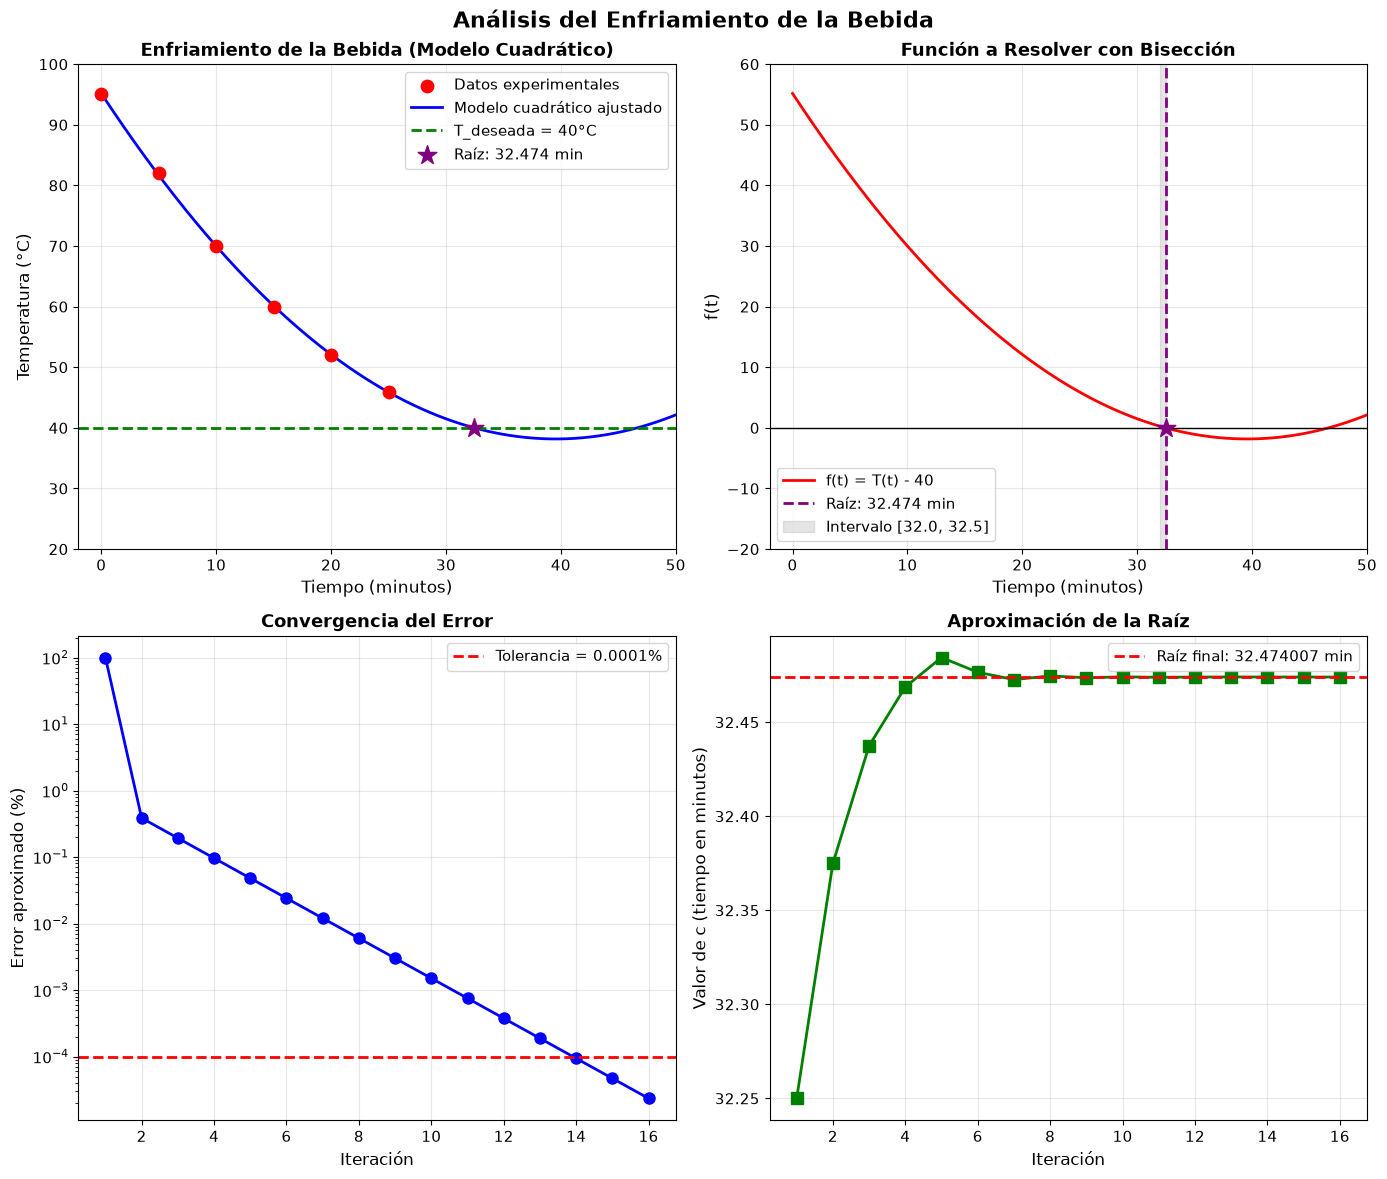

In [12]:
print("10. GENERANDO GRÁFICAS...")

# Crear figura principal
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Análisis del Enfriamiento de la Bebida', fontsize=16, fontweight='bold')

# ====== GRÁFICA 1: Enfriamiento (Cuadrático) ======
ax1 = axes[0, 0]
t_suave = np.linspace(0, 50, 500)
T_suave = T_cuadratico(t_suave, a, b, c)

ax1.scatter(t, T, color='red', s=80, label='Datos experimentales', zorder=5)
ax1.plot(t_suave, T_suave, 'b-', linewidth=2, label='Modelo cuadrático ajustado')
ax1.axhline(y=T_deseada, color='green', linestyle='--', 
    linewidth=2, label=f'T_deseada = {T_deseada}°C')
ax1.scatter(raiz, T_raiz, color='purple', s=200, 
    marker='*', label=f'Raíz: {raiz:.3f} min', zorder=10)

ax1.set_xlabel('Tiempo (minutos)', fontsize=12)
ax1.set_ylabel('Temperatura (°C)', fontsize=12)
ax1.set_title('Enfriamiento de la Bebida (Modelo Cuadrático)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
ax1.set_xlim(-2, 50)
ax1.set_ylim(20, 100)

# ====== GRÁFICA 2: Función f(t) ======
ax2 = axes[0, 1]
f_t = T_cuadratico(t_suave, a, b, c) - T_deseada

ax2.plot(t_suave, f_t, 'r-', linewidth=2, label='f(t) = T(t) - 40')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=raiz, color='purple', linestyle='--', 
    linewidth=2, label=f'Raíz: {raiz:.3f} min')

# Marcar el intervalo inicial
ax2.fill_between([t_a, t_b], -20, 80, alpha=0.2, color='gray',
    label=f'Intervalo [{t_a:.1f}, {t_b:.1f}]')
ax2.scatter(raiz, 0, color='purple', s=200, marker='*', zorder=10)

ax2.set_xlabel('Tiempo (minutos)', fontsize=12)
ax2.set_ylabel('f(t)', fontsize=12)
ax2.set_title('Función a Resolver con Bisección', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')
ax2.set_xlim(-2, 50)
ax2.set_ylim(-20, 60)

# ====== GRÁFICA 3: Convergencia del Error ======
ax3 = axes[1, 0]
iter_num = df_iter['Iteración'].values
errores = df_iter['Error %'].values

ax3.semilogy(iter_num, errores, 'bo-', linewidth=2, markersize=8)
ax3.set_xlabel('Iteración', fontsize=12)
ax3.set_ylabel('Error aproximado (%)', fontsize=12)
ax3.set_title('Convergencia del Error', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=tolerancia*100, color='red', linestyle='--', 
    linewidth=2, label=f'Tolerancia = {tolerancia*100:.4f}%')
ax3.legend(loc='best')

# ====== GRÁFICA 4: Aproximación de la Raíz ======
ax4 = axes[1, 1]
valores_c = df_iter['c'].values

ax4.plot(iter_num, valores_c, 'g-s', linewidth=2, markersize=8)
ax4.axhline(y=raiz, color='red', linestyle='--', 
    linewidth=2, label=f'Raíz final: {raiz:.6f} min')
ax4.set_xlabel('Iteración', fontsize=12)
ax4.set_ylabel('Valor de c (tiempo en minutos)', fontsize=12)
ax4.set_title('Aproximación de la Raíz', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='best')

plt.tight_layout()
plt.savefig('graficas_completas.png', dpi=300, bbox_inches='tight')
print(" Gráficas completas guardadas como 'graficas_completas.png'")
plt.show()

**_11. GRÁFICA COMPARATIVA: MODELO CUADRÁTICO vs EXPONENCIAL_**

 Gráfica comparativa guardada como 'comparacion_modelos.png'


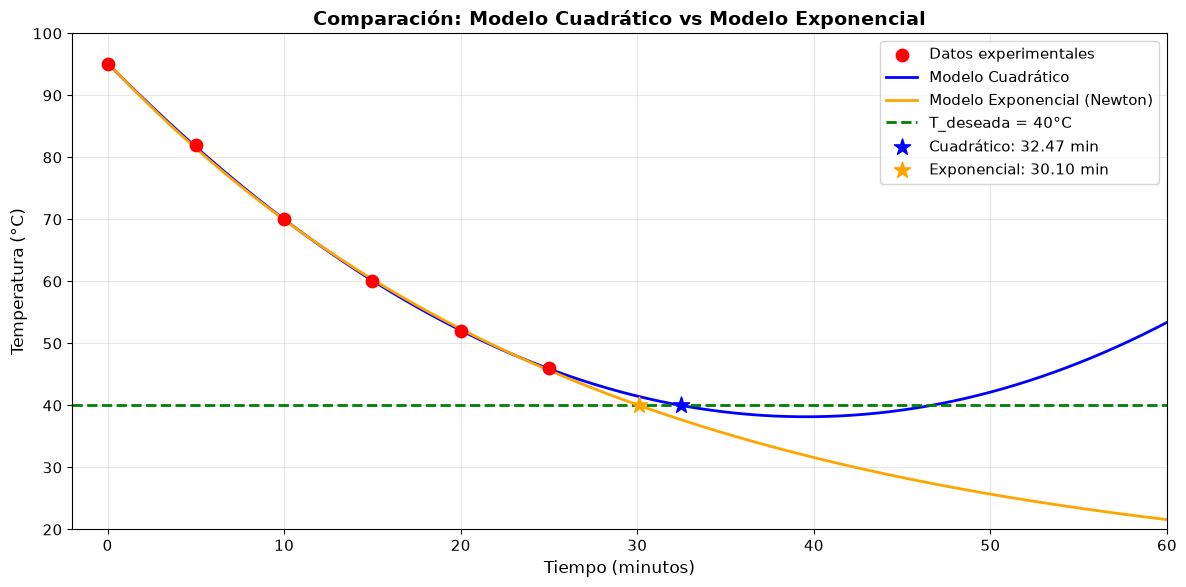

In [13]:
if 't_a_exp' in locals() and t_a_exp is not None:
    fig2, ax5 = plt.subplots(1, 1, figsize=(12, 6))
    
    # Curvas de enfriamiento
    t_suave = np.linspace(0, 60, 500)
    T_cuad = T_cuadratico(t_suave, a, b, c)
    T_exp = T_exponencial(t_suave, T0_exp, Ta_exp, k_exp)
    
    ax5.scatter(t, T, color='red', s=80, label='Datos experimentales', zorder=5)
    ax5.plot(t_suave, T_cuad, 'b-', linewidth=2, label='Modelo Cuadrático')
    ax5.plot(t_suave, T_exp, 'orange', linewidth=2, label='Modelo Exponencial (Newton)')
    ax5.axhline(y=T_deseada, color='green', linestyle='--', 
                linewidth=2, label=f'T_deseada = {T_deseada}°C')
    
    # Puntos de intersección
    ax5.scatter(raiz, T_raiz, color='blue', s=150, 
                marker='*', label=f'Cuadrático: {raiz:.2f} min', zorder=10)
    ax5.scatter(raiz_exp, T_raiz_exp, color='orange', s=150, 
                marker='*', label=f'Exponencial: {raiz_exp:.2f} min', zorder=10)
    
    ax5.set_xlabel('Tiempo (minutos)', fontsize=12)
    ax5.set_ylabel('Temperatura (°C)', fontsize=12)
    ax5.set_title('Comparación: Modelo Cuadrático vs Modelo Exponencial', 
        fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend(loc='best')
    ax5.set_xlim(-2, 60)
    ax5.set_ylim(20, 100)
    
    plt.tight_layout()
    plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
    print(" Gráfica comparativa guardada como 'comparacion_modelos.png'")
    plt.show()

**_12. RESUMEN FINAL COMPLETO_**

In [14]:
print("11. RESUMEN FINAL DEL PROYECTO")

print(f"""
DATOS DEL PROBLEMA:
────────────────────────────────────────────────────────
  Temperatura inicial:        95.0 °C
  Temperatura objetivo:       {T_deseada} °C
  Rango de tiempo:            0 - 25 minutos
  Número de datos:            6

MODELO CUADRÁTICO:
────────────────────────────────────────────────────────
  T(t) = {a:.6f}t² + {b:.6f}t + {c:.6f}
  Coeficiente de determinación R² = {r2:.6f}
  El modelo explica el {r2*100:.2f}% de la variación

MÉTODO DE BISECCIÓN:
────────────────────────────────────────────────────────
  Intervalo inicial:          [{t_a:.3f}, {t_b:.3f}]
  Tolerancia:                 {tolerancia}
  Iteraciones realizadas:     {n_iter}
  Error final:                {df_iter.iloc[-1]['Error %']:.6f}%

RESULTADO PRINCIPAL:
────────────────────────────────────────────────────────
  Tiempo para alcanzar {T_deseada}°C:  {raiz:.6f} minutos
  Equivalente en mm:ss:               {minutos} min {segundos:02d} seg
  Temperatura en ese tiempo:          {T_raiz:.6f} °C""")

if t_analitico is not None:
    print(f"""  Solución analítica exacta:     {t_analitico:.6f} minutos
  Error verdadero:               {error_verdadero:.6f}%""")

print(f"""
ANÁLISIS DE SENSIBILIDAD (resumen):
────────────────────────────────────────────────────────
  Tolerancia más estricta:      {tolerancias[-1]}
  Iteraciones para alcanzarla:  {resultados_sensibilidad[-1]['Iteraciones']}
  Tiempo obtenido:              {resultados_sensibilidad[-1]['Tiempo (min)']:.6f} min""")

if 't_a_exp' in locals() and t_a_exp is not None:
    print(f"""
COMPARACIÓN DE MODELOS:
────────────────────────────────────────────────────────
  Modelo cuadrático:            {raiz:.4f} min
  Modelo exponencial:           {raiz_exp:.4f} min
  Diferencia:                   {abs(raiz - raiz_exp):.4f} min
  El modelo exponencial (Ley de Newton) es 
  físicamente más realista porque predice un 
  enfriamiento asintótico hacia la temperatura ambiente.""")

print("""
ARCHIVOS GENERADOS:
────────────────────────────────────────────────────────
  1. iteraciones_biseccion.csv    (Tabla de iteraciones)
  2. analisis_sensibilidad.csv    (Análisis de sensibilidad)
  3. graficas_completas.png       (Gráficas principales)
  4. comparacion_modelos.png      (Comparación de modelos)
""")


11. RESUMEN FINAL DEL PROYECTO

DATOS DEL PROBLEMA:
────────────────────────────────────────────────────────
  Temperatura inicial:        95.0 °C
  Temperatura objetivo:       40 °C
  Rango de tiempo:            0 - 25 minutos
  Número de datos:            6

MODELO CUADRÁTICO:
────────────────────────────────────────────────────────
  T(t) = 0.036429t² + -2.882143t + 95.178571
  Coeficiente de determinación R² = 0.999897
  El modelo explica el 99.99% de la variación

MÉTODO DE BISECCIÓN:
────────────────────────────────────────────────────────
  Intervalo inicial:          [32.000, 32.500]
  Tolerancia:                 1e-06
  Iteraciones realizadas:     16
  Error final:                0.000023%

RESULTADO PRINCIPAL:
────────────────────────────────────────────────────────
  Tiempo para alcanzar 40°C:  32.474007 minutos
  Equivalente en mm:ss:               32 min 28 seg
  Temperatura en ese tiempo:          40.000000 °C
  Solución analítica exacta:     32.474006 minutos
  Error ver